# 05 Advanced Models (Week 7)

This notebook completes the Week 7 advanced-modeling task by testing XGBoost, adding light hyperparameter tuning, and comparing the advanced models against the retained linear-regression baseline on the same time-based holdout month.

## Week 7 Goal

The goal for Week 7 is to test whether a stronger model family can improve price prediction while keeping the evaluation methodology consistent.

The earlier raw-price XGBoost attempt produced unstable predictions on the long-tailed housing-price data. This version uses a more realistic setup:

- XGBoost predicts `log(ClosePrice)` and converts predictions back to dollars for evaluation.
- Several feature sets are tested, from the original baseline features to richer market-context features.
- A validation month is used for light tuning before final evaluation on the unchanged test month.
- Final results use the same metrics as earlier weeks: `R2`, `MAPE`, `MdAPE`, `MAE`, and `RMSE`.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "XGBoost is not installed. Run `pip install xgboost` in the same environment as this notebook, then rerun this cell."
    ) from exc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
output_dir = Path("../outputs")
engineered_path = output_dir / "week6_feature_engineered_dataset.csv"
base_path = output_dir / "full_preprocessed_week3.csv"

print(f"Engineered dataset path: {engineered_path}")
print(f"Base dataset path: {base_path}")

Engineered dataset path: ../outputs/week6_feature_engineered_dataset.csv
Base dataset path: ../outputs/full_preprocessed_week3.csv


## Load Data

This notebook prefers the Week 6 enriched dataset because it already contains the engineered features and school district mapping. If that file is not available, it falls back to the Week 3 preprocessed dataset and recreates the core engineered features.

In [2]:
if engineered_path.exists():
    df = pd.read_csv(engineered_path)
    print("Loaded Week 6 feature-engineered dataset.")
elif base_path.exists():
    df = pd.read_csv(base_path)
    print("Loaded Week 3 preprocessed dataset and will recreate engineered features.")
else:
    raise FileNotFoundError(
        "Run earlier preprocessing notebooks first so model-ready data exists."
    )

df["CloseDate"] = pd.to_datetime(df["CloseDate"])
df["close_month"] = pd.to_datetime(df["close_month"])

living_area_safe = df["LivingArea"].replace(0, np.nan)
if "list_price_per_sqft" not in df.columns:
    df["list_price_per_sqft"] = df["ListPrice"] / living_area_safe
if "lot_to_living_ratio" not in df.columns:
    df["lot_to_living_ratio"] = df["LotSizeSquareFeet"] / living_area_safe
if "is_newer_home" not in df.columns:
    df["is_newer_home"] = (df["YearBuilt"] >= 2000).astype(int)
if "high_bedroom_flag" not in df.columns:
    df["high_bedroom_flag"] = (df["BedroomsTotal"] >= 4).astype(int)
if "bedrooms_per_1000_sqft" not in df.columns:
    df["bedrooms_per_1000_sqft"] = df["BedroomsTotal"] / (living_area_safe / 1000)
if "log_lot_size" not in df.columns:
    df["log_lot_size"] = np.log1p(df["LotSizeSquareFeet"].clip(lower=0))
if "log_days_on_market" not in df.columns:
    df["log_days_on_market"] = np.log1p(df["DaysOnMarket"].clip(lower=0))
if "living_area_per_bedroom" not in df.columns:
    df["living_area_per_bedroom"] = living_area_safe / df["BedroomsTotal"].replace(
        0, np.nan
    )
if "unified_district_name" not in df.columns:
    df["unified_district_name"] = "Unknown_District"
if "is_unknown_district" not in df.columns:
    df["is_unknown_district"] = (
        df["unified_district_name"] == "Unknown_District"
    ).astype(int)

available_months = sorted(df["close_month"].dropna().unique())
test_month = available_months[-1]
train_months = available_months[-7:-1]

train_df = df[df["close_month"].isin(train_months)].copy()
test_df = df[df["close_month"] == test_month].copy()

print(f"Full rows: {len(df):,}")
print(f"Train months: {[pd.Timestamp(m).strftime('%Y-%m') for m in train_months]}")
print(f"Test month: {pd.Timestamp(test_month).strftime('%Y-%m')}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")

display(df.head())

Loaded Week 6 feature-engineered dataset.
Full rows: 71,526
Train months: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
Test month: 2026-05
Train rows: 59,505
Test rows: 12,021


,ClosePrice,CloseDate,close_month,ListPrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,Latitude,Longitude,DaysOnMarket,property_age,log_living_area,bathrooms_per_bedroom,CountyOrParish,list_price_per_sqft,lot_to_living_ratio,is_newer_home,high_bedroom_flag,bedrooms_per_1000_sqft,log_lot_size,log_days_on_market,living_area_per_bedroom,unified_district_name,is_unknown_district
0,1250000.0000,2025-11-30,2025-11-01,1250000.0000,1027.0000,3.0000,2.0000,5913.0000,1961.0000,33.6760,-117.9952,0.0000,64.0000,6.9354,0.6667,Orange,1217.1373,5.7575,0,0,2.9211,8.6851,0.0000,342.3333,Unknown_District,1
1,2299995.0000,2025-11-20,2025-11-01,2299995.0000,1129.0000,3.0000,1.0000,18432.0000,1949.0000,37.2607,-121.9341,0.0000,76.0000,7.0300,0.3333,Santa Clara,2037.1966,16.3260,0,0,2.6572,9.8219,0.0000,376.3333,Unknown_District,1
2,810000.0000,2025-11-26,2025-11-01,799900.0000,1619.0000,4.0000,3.0000,5300.0000,1978.0000,32.5650,-117.0644,0.0000,47.0000,7.3902,0.7500,San Diego,494.0704,3.2736,0,1,2.4707,8.5757,0.0000,404.7500,Unknown_District,1
3,925000.0000,2025-11-17,2025-11-01,925000.0000,2872.0000,5.0000,3.0000,5272.0000,2000.0000,32.5758,-117.0244,0.0000,25.0000,7.9631,0.6000,San Diego,322.0752,1.8357,1,1,1.7409,8.5704,0.0000,574.4000,Unknown_District,1
4,1300000.0000,2025-11-25,2025-11-01,1300000.0000,1727.0000,3.0000,2.0000,10500.0000,1950.0000,35.5531,-120.7085,0.0000,75.0000,7.4547,0.6667,San Luis Obispo,752.7504,6.0799,0,0,1.7371,9.2592,0.0000,575.6667,Templeton Unified,0


## Feature Strategy

This model tries to represent real housing-price drivers more directly:

- Property size and room structure: living area, lot size, bedrooms, bathrooms
- Age and timing: year built, property age, days on market
- Listing signal: list price and list price per square foot
- Location: county and unified school district
- Historical market context: county and district-level median sale price from the training period only

The historical market features are calculated from the training period and then mapped onto validation or test rows. This keeps the test month unseen.

In [3]:
target_col = "ClosePrice"

baseline_features = [
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "DaysOnMarket",
    "property_age",
    "log_living_area",
    "bathrooms_per_bedroom",
    "CountyOrParish",
]

reality_features = baseline_features + [
    "list_price_per_sqft",
    "lot_to_living_ratio",
    "is_newer_home",
    "high_bedroom_flag",
    "bedrooms_per_1000_sqft",
    "log_lot_size",
    "log_days_on_market",
    "living_area_per_bedroom",
    "is_unknown_district",
    "unified_district_name",
]

market_context_features = reality_features + [
    "county_hist_median_closeprice",
    "county_hist_median_list_ppsf",
    "county_hist_transaction_count",
    "district_hist_median_closeprice",
    "district_hist_transaction_count",
]

for feature_list_name, feature_list in {
    "baseline_features": baseline_features,
    "reality_features": reality_features,
}.items():
    missing_cols = [col for col in feature_list if col not in df.columns]
    if missing_cols:
        raise ValueError(f"{feature_list_name} is missing columns: {missing_cols}")

print(f"Baseline feature count: {len(baseline_features)}")
print(f"Reality feature count: {len(reality_features)}")
print(f"Market context feature count: {len(market_context_features)}")

Baseline feature count: 13
Reality feature count: 23
Market context feature count: 28


## Validation Split

For tuning, the most recent training month is used as validation. The final test month remains untouched until final evaluation.

In [4]:
validation_month = sorted(train_df["close_month"].dropna().unique())[-1]
tuning_train_df = train_df[train_df["close_month"] < validation_month].copy()
validation_df = train_df[train_df["close_month"] == validation_month].copy()

print(
    f"Tuning train months: {sorted(tuning_train_df['close_month'].dt.strftime('%Y-%m').unique())}"
)
print(f"Validation month: {pd.Timestamp(validation_month).strftime('%Y-%m')}")
print(f"Tuning train rows: {len(tuning_train_df):,}")
print(f"Validation rows: {len(validation_df):,}")

Tuning train months: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03']
Validation month: 2026-04
Tuning train rows: 47,471
Validation rows: 12,034


## Helper Functions

These functions keep preprocessing, market-context feature creation, log-target modeling, and metrics consistent across experiments.

In [5]:
def evaluate_predictions(y_true, preds):
    y_true_series = pd.Series(y_true).reset_index(drop=True)
    pred_series = pd.Series(preds).reset_index(drop=True)
    ape = (y_true_series - pred_series).abs() / y_true_series
    return {
        "MAE": mean_absolute_error(y_true_series, pred_series),
        "RMSE": np.sqrt(mean_squared_error(y_true_series, pred_series)),
        "R2": r2_score(y_true_series, pred_series),
        "MAPE": ape.mean(),
        "MdAPE": ape.median(),
    }


def add_market_context(fit_df, apply_df):
    fit_df = fit_df.copy()
    apply_df = apply_df.copy()
    fit_df["fit_list_ppsf"] = fit_df["ListPrice"] / fit_df["LivingArea"].replace(
        0, np.nan
    )

    global_median_close = fit_df["ClosePrice"].median()
    global_median_ppsf = fit_df["fit_list_ppsf"].median()

    county_stats = fit_df.groupby("CountyOrParish").agg(
        county_hist_median_closeprice=("ClosePrice", "median"),
        county_hist_median_list_ppsf=("fit_list_ppsf", "median"),
        county_hist_transaction_count=("ClosePrice", "size"),
    )

    district_stats = fit_df.groupby("unified_district_name").agg(
        district_hist_median_closeprice=("ClosePrice", "median"),
        district_hist_transaction_count=("ClosePrice", "size"),
    )

    apply_df = apply_df.merge(county_stats, on="CountyOrParish", how="left")
    apply_df = apply_df.merge(district_stats, on="unified_district_name", how="left")

    apply_df["county_hist_median_closeprice"] = apply_df[
        "county_hist_median_closeprice"
    ].fillna(global_median_close)
    apply_df["county_hist_median_list_ppsf"] = apply_df[
        "county_hist_median_list_ppsf"
    ].fillna(global_median_ppsf)
    apply_df["county_hist_transaction_count"] = apply_df[
        "county_hist_transaction_count"
    ].fillna(0)
    apply_df["district_hist_median_closeprice"] = apply_df[
        "district_hist_median_closeprice"
    ].fillna(global_median_close)
    apply_df["district_hist_transaction_count"] = apply_df[
        "district_hist_transaction_count"
    ].fillna(0)
    return apply_df


def make_preprocessor(feature_cols, fit_frame, scale_numeric=False):
    numeric_features = (
        fit_frame[feature_cols].select_dtypes(include=["number"]).columns.tolist()
    )
    categorical_features = [col for col in feature_cols if col not in numeric_features]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=numeric_steps)
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=25)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )


def build_linear_model(feature_cols, fit_frame):
    return Pipeline(
        steps=[
            (
                "preprocess",
                make_preprocessor(feature_cols, fit_frame, scale_numeric=True),
            ),
            ("model", LinearRegression()),
        ]
    )


def build_xgb_model(
    feature_cols, fit_frame, max_depth, learning_rate, n_estimators, min_child_weight
):
    xgb = XGBRegressor(
        objective="reg:squarederror",
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        min_child_weight=min_child_weight,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=8.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    )

    return Pipeline(
        steps=[
            (
                "preprocess",
                make_preprocessor(feature_cols, fit_frame, scale_numeric=False),
            ),
            ("model", xgb),
        ]
    )


def prepare_experiment_frames(train_source_df, eval_source_df, feature_set_name):
    if feature_set_name == "baseline":
        feature_cols = baseline_features
        train_ready = train_source_df.copy()
        eval_ready = eval_source_df.copy()
    elif feature_set_name == "reality":
        feature_cols = reality_features
        train_ready = train_source_df.copy()
        eval_ready = eval_source_df.copy()
    elif feature_set_name == "market_context":
        feature_cols = market_context_features
        train_ready = add_market_context(train_source_df, train_source_df)
        eval_ready = add_market_context(train_source_df, eval_source_df)
    else:
        raise ValueError(f"Unknown feature set: {feature_set_name}")
    return train_ready, eval_ready, feature_cols


def train_predict_xgb_log(train_ready, eval_ready, feature_cols, params):
    model = build_xgb_model(feature_cols, train_ready, **params)
    model.fit(train_ready[feature_cols], np.log1p(train_ready[target_col]))
    log_preds = model.predict(eval_ready[feature_cols])
    preds = np.expm1(log_preds)
    preds = np.clip(preds, 0, None)
    return model, preds


## Linear Regression Reference

The advanced models are compared against the retained linear-regression baseline from earlier weeks.

In [6]:
linear_model = build_linear_model(baseline_features, train_df)
linear_model.fit(train_df[baseline_features], train_df[target_col])
linear_test_preds = linear_model.predict(test_df[baseline_features])
linear_metrics = evaluate_predictions(test_df[target_col], linear_test_preds)

display(pd.DataFrame([{"model_name": "LinearRegression", **linear_metrics}]))

,model_name,MAE,RMSE,R2,MAPE,MdAPE
0,LinearRegression,176033.5133,1009587.8902,0.6372,0.1953,0.0825


## XGBoost Experiments And Light Tuning

This section tests several realistic XGBoost setups. Each setup gets a small tuning grid, and the best version is selected using validation `MAPE`, `MdAPE`, prediction sanity checks, and `R2`.

In [7]:
param_grid = [
    {
        "max_depth": 2,
        "learning_rate": 0.03,
        "n_estimators": 500,
        "min_child_weight": 10,
    },
    {
        "max_depth": 2,
        "learning_rate": 0.05,
        "n_estimators": 400,
        "min_child_weight": 10,
    },
    {
        "max_depth": 3,
        "learning_rate": 0.03,
        "n_estimators": 600,
        "min_child_weight": 15,
    },
    {
        "max_depth": 3,
        "learning_rate": 0.05,
        "n_estimators": 450,
        "min_child_weight": 25,
    },
]

experiment_specs = [
    {
        "experiment_name": "xgb_log_baseline_all",
        "feature_set": "baseline",
        "filter_train": False,
    },
    {
        "experiment_name": "xgb_log_reality_all",
        "feature_set": "reality",
        "filter_train": False,
    },
    {
        "experiment_name": "xgb_log_market_context_all",
        "feature_set": "market_context",
        "filter_train": False,
    },
    {
        "experiment_name": "xgb_log_market_context_filtered",
        "feature_set": "market_context",
        "filter_train": True,
    },
]


def apply_training_filter(frame):
    return frame.loc[
        (frame["ClosePrice"] >= 100000)
        & (frame["ClosePrice"] <= 20000000)
        & (frame["LivingArea"] >= 400)
    ].copy()


tuning_rows = []

for spec in experiment_specs:
    base_tune_train = tuning_train_df.copy()
    if spec["filter_train"]:
        base_tune_train = apply_training_filter(base_tune_train)

    tune_train_ready, valid_ready, feature_cols = prepare_experiment_frames(
        base_tune_train, validation_df, spec["feature_set"]
    )

    for params in param_grid:
        model, valid_preds = train_predict_xgb_log(
            tune_train_ready, valid_ready, feature_cols, params
        )
        metrics = evaluate_predictions(valid_ready[target_col], valid_preds)
        sanity_checks = {
            "min_prediction": valid_preds.min(),
            "max_prediction": valid_preds.max(),
            "predictions_over_50m": int((valid_preds > 50000000).sum()),
        }
        tuning_rows.append(
            {
                **spec,
                **params,
                "feature_count": len(feature_cols),
                "tuning_train_rows": len(tune_train_ready),
                "validation_rows": len(valid_ready),
                **metrics,
                **sanity_checks,
            }
        )

tuning_results_df = pd.DataFrame(tuning_rows)
tuning_results_df = tuning_results_df.sort_values(
    ["predictions_over_50m", "MAPE", "MdAPE", "R2"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

display(tuning_results_df.head(12))

,experiment_name,feature_set,filter_train,max_depth,learning_rate,n_estimators,min_child_weight,feature_count,tuning_train_rows,validation_rows,MAE,RMSE,R2,MAPE,MdAPE,min_prediction,max_prediction,predictions_over_50m
0,xgb_log_market_context_filtered,market_context,True,3,0.0500,450,25,28,47378,12034,253611.0685,11675395.3876,0.0130,0.0411,0.0253,129072.3359,19056528.0000,0
1,xgb_log_market_context_filtered,market_context,True,3,0.0300,600,15,28,47378,12034,254225.7084,11675175.4452,0.0131,0.0413,0.0255,130958.7422,18883614.0000,0
2,xgb_log_market_context_all,market_context,False,3,0.0300,600,15,28,47471,12034,252916.2481,11670688.7005,0.0138,0.0417,0.0259,77709.3047,24880582.0000,0
3,xgb_log_market_context_all,market_context,False,3,0.0500,450,25,28,47471,12034,253437.7943,11670788.9526,0.0138,0.0418,0.0259,73541.1562,23764684.0000,0
4,xgb_log_reality_all,reality,False,3,0.0300,600,15,23,47471,12034,253774.9227,11670018.4324,0.0139,0.0420,0.0263,80585.2188,24442432.0000,0
5,xgb_log_reality_all,reality,False,3,0.0500,450,25,23,47471,12034,253833.7285,11670670.3005,0.0138,0.0422,0.0265,80857.6562,23284552.0000,0
6,xgb_log_baseline_all,baseline,False,3,0.0500,450,25,13,47471,12034,258746.4240,11674591.8352,0.0132,0.0425,0.0260,87015.0625,16781056.0000,0
7,xgb_log_baseline_all,baseline,False,3,0.0300,600,15,13,47471,12034,259036.6995,11675638.4984,0.0130,0.0426,0.0262,95912.6719,16757068.0000,0
8,xgb_log_reality_all,reality,False,2,0.0500,400,10,23,47471,12034,255256.8442,11672388.1863,0.0135,0.0429,0.0268,81558.0859,23186166.0000,0
9,xgb_log_baseline_all,baseline,False,2,0.0500,400,10,13,47471,12034,260005.7345,11676934.3333,0.0128,0.0431,0.0263,102686.8125,16078579.0000,0


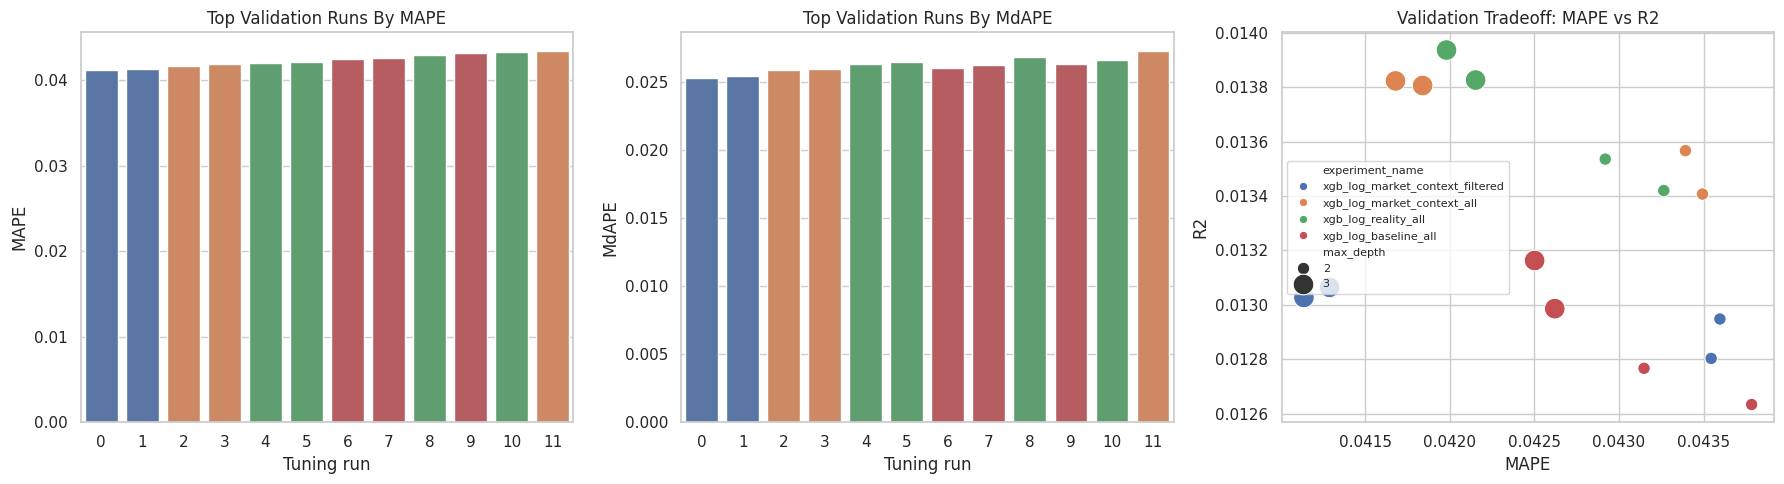

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_tuning = tuning_results_df.head(12).copy()
sns.barplot(
    data=top_tuning, x=top_tuning.index, y="MAPE", hue="experiment_name", ax=axes[0]
)
axes[0].set_title("Top Validation Runs By MAPE")
axes[0].set_xlabel("Tuning run")

sns.barplot(
    data=top_tuning, x=top_tuning.index, y="MdAPE", hue="experiment_name", ax=axes[1]
)
axes[1].set_title("Top Validation Runs By MdAPE")
axes[1].set_xlabel("Tuning run")

sns.scatterplot(
    data=tuning_results_df,
    x="MAPE",
    y="R2",
    hue="experiment_name",
    size="max_depth",
    sizes=(80, 220),
    ax=axes[2],
)
axes[2].set_title("Validation Tradeoff: MAPE vs R2")

for ax in axes[:2]:
    ax.legend_.remove()
axes[2].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

## Final Test Evaluation

For each XGBoost experiment type, this section takes the best validation configuration, retrains on the full training window, and evaluates once on the unchanged test month.

In [9]:
best_by_experiment = (
    tuning_results_df.sort_values(
        ["predictions_over_50m", "MAPE", "MdAPE", "R2"],
        ascending=[True, True, True, False],
    )
    .groupby("experiment_name", as_index=False)
    .first()
)

final_rows = [{"model_name": "LinearRegression", **linear_metrics}]
final_predictions = {
    "LinearRegression": linear_test_preds,
}
final_models = {}

for _, row in best_by_experiment.iterrows():
    spec = next(
        item
        for item in experiment_specs
        if item["experiment_name"] == row["experiment_name"]
    )
    final_train_source = train_df.copy()
    if spec["filter_train"]:
        final_train_source = apply_training_filter(final_train_source)

    final_train_ready, final_test_ready, feature_cols = prepare_experiment_frames(
        final_train_source, test_df, spec["feature_set"]
    )

    params = {
        "max_depth": int(row["max_depth"]),
        "learning_rate": float(row["learning_rate"]),
        "n_estimators": int(row["n_estimators"]),
        "min_child_weight": int(row["min_child_weight"]),
    }

    model, test_preds = train_predict_xgb_log(
        final_train_ready, final_test_ready, feature_cols, params
    )
    metrics = evaluate_predictions(final_test_ready[target_col], test_preds)
    sanity_checks = {
        "min_prediction": test_preds.min(),
        "max_prediction": test_preds.max(),
        "predictions_over_50m": int((test_preds > 50000000).sum()),
    }

    model_name = row["experiment_name"]
    final_rows.append(
        {
            "model_name": model_name,
            "feature_set": spec["feature_set"],
            "filtered_training": spec["filter_train"],
            "feature_count": len(feature_cols),
            "train_rows": len(final_train_ready),
            **params,
            **metrics,
            **sanity_checks,
        }
    )
    final_predictions[model_name] = test_preds
    final_models[model_name] = model

final_results_df = (
    pd.DataFrame(final_rows)
    .sort_values(["R2", "MAPE"], ascending=[False, True])
    .reset_index(drop=True)
)

display(final_results_df)

best_advanced_name = final_results_df.loc[
    final_results_df["model_name"] != "LinearRegression", "model_name"
].iloc[0]
best_overall_name = final_results_df.loc[0, "model_name"]
print(f"Best advanced model: {best_advanced_name}")
print(f"Best overall model: {best_overall_name}")

,model_name,MAE,RMSE,R2,MAPE,MdAPE,feature_set,filtered_training,feature_count,train_rows,max_depth,learning_rate,n_estimators,min_child_weight,min_prediction,max_prediction,predictions_over_50m
0,LinearRegression,176033.5133,1009587.8902,0.6372,0.1953,0.0825,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,xgb_log_market_context_all,75748.9291,1013238.9295,0.6345,0.0724,0.0251,market_context,False,28.0000,59505.0000,3.0000,0.0300,600.0000,15.0000,72940.5312,26379218.0000,0.0000
2,xgb_log_reality_all,75476.9368,1013314.4238,0.6345,0.0728,0.0253,reality,False,23.0000,59505.0000,3.0000,0.0300,600.0000,15.0000,67936.2578,25502302.0000,0.0000
3,xgb_log_market_context_filtered,76023.7264,1031333.8922,0.6214,0.0720,0.0243,market_context,True,28.0000,59390.0000,3.0000,0.0500,450.0000,25.0000,111449.8359,18026948.0000,0.0000
4,xgb_log_baseline_all,82620.9954,1043080.7636,0.6127,0.0741,0.0262,baseline,False,13.0000,59505.0000,3.0000,0.0500,450.0000,25.0000,81742.9453,18564736.0000,0.0000


Best advanced model: xgb_log_market_context_all
Best overall model: LinearRegression


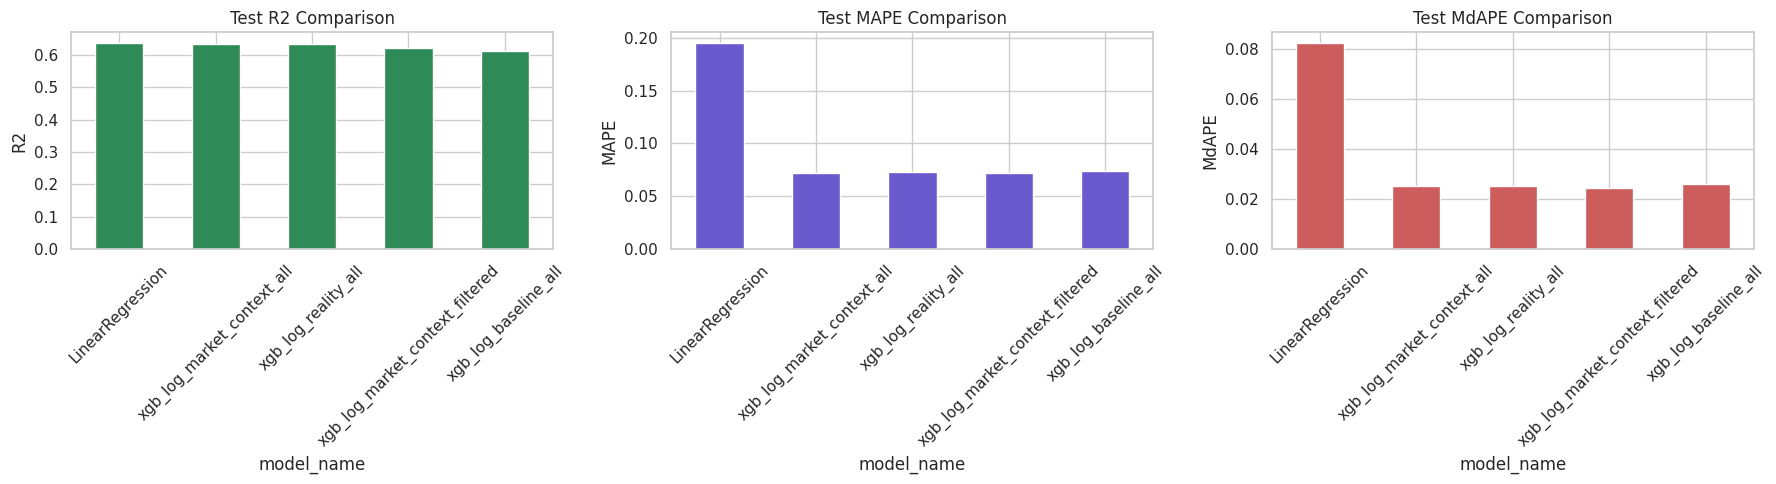

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

final_results_df.plot(
    x="model_name", y="R2", kind="bar", legend=False, ax=axes[0], color="seagreen"
)
axes[0].set_title("Test R2 Comparison")
axes[0].set_ylabel("R2")

final_results_df.plot(
    x="model_name", y="MAPE", kind="bar", legend=False, ax=axes[1], color="slateblue"
)
axes[1].set_title("Test MAPE Comparison")
axes[1].set_ylabel("MAPE")

final_results_df.plot(
    x="model_name", y="MdAPE", kind="bar", legend=False, ax=axes[2], color="indianred"
)
axes[2].set_title("Test MdAPE Comparison")
axes[2].set_ylabel("MdAPE")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Prediction Diagnostics

These plots show how the best advanced model behaves on the test month. They are useful for explaining whether the model is stable, where it overpredicts or underpredicts, and whether extreme homes are still driving errors.

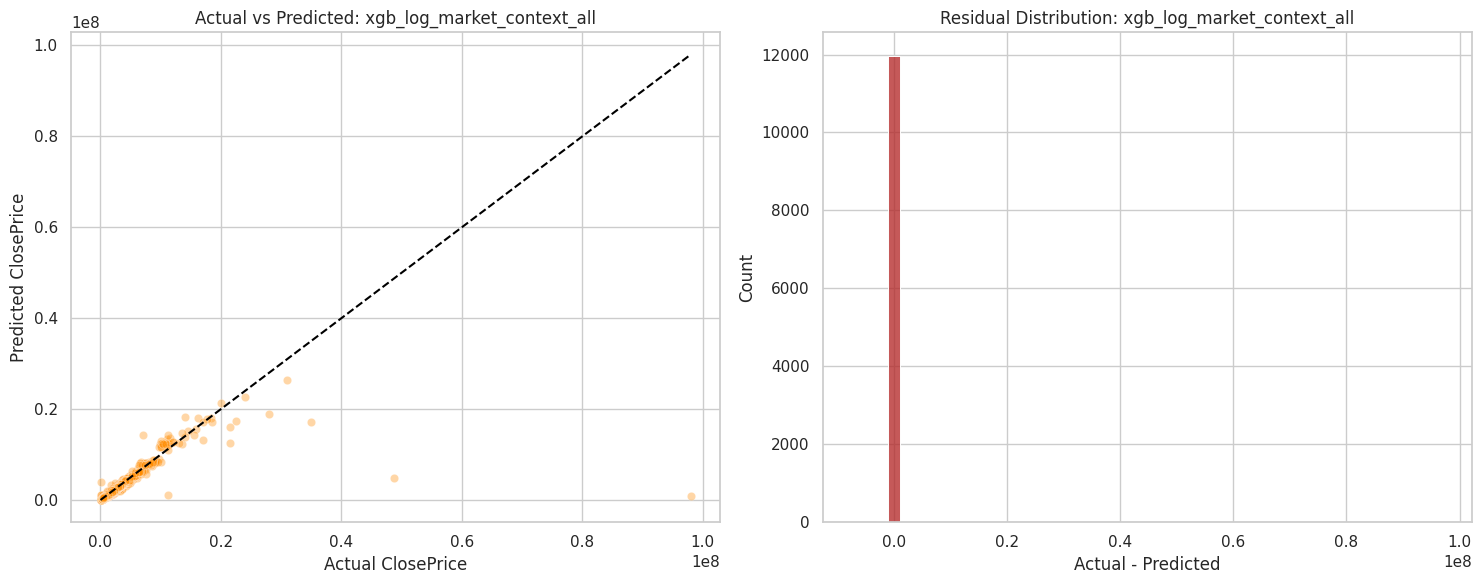

In [11]:
best_advanced_preds = final_predictions[best_advanced_name]
prediction_df = pd.DataFrame(
    {
        "actual": test_df[target_col].values,
        "linear_predicted": linear_test_preds,
        "best_advanced_predicted": best_advanced_preds,
    }
)
prediction_df["linear_residual"] = (
    prediction_df["actual"] - prediction_df["linear_predicted"]
)
prediction_df["advanced_residual"] = (
    prediction_df["actual"] - prediction_df["best_advanced_predicted"]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=prediction_df,
    x="actual",
    y="best_advanced_predicted",
    alpha=0.35,
    ax=axes[0],
    color="darkorange",
)
line_min = min(
    prediction_df["actual"].min(), prediction_df["best_advanced_predicted"].min()
)
line_max = max(
    prediction_df["actual"].max(), prediction_df["best_advanced_predicted"].max()
)
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
axes[0].set_title(f"Actual vs Predicted: {best_advanced_name}")
axes[0].set_xlabel("Actual ClosePrice")
axes[0].set_ylabel("Predicted ClosePrice")

sns.histplot(prediction_df["advanced_residual"], bins=50, ax=axes[1], color="firebrick")
axes[1].set_title(f"Residual Distribution: {best_advanced_name}")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

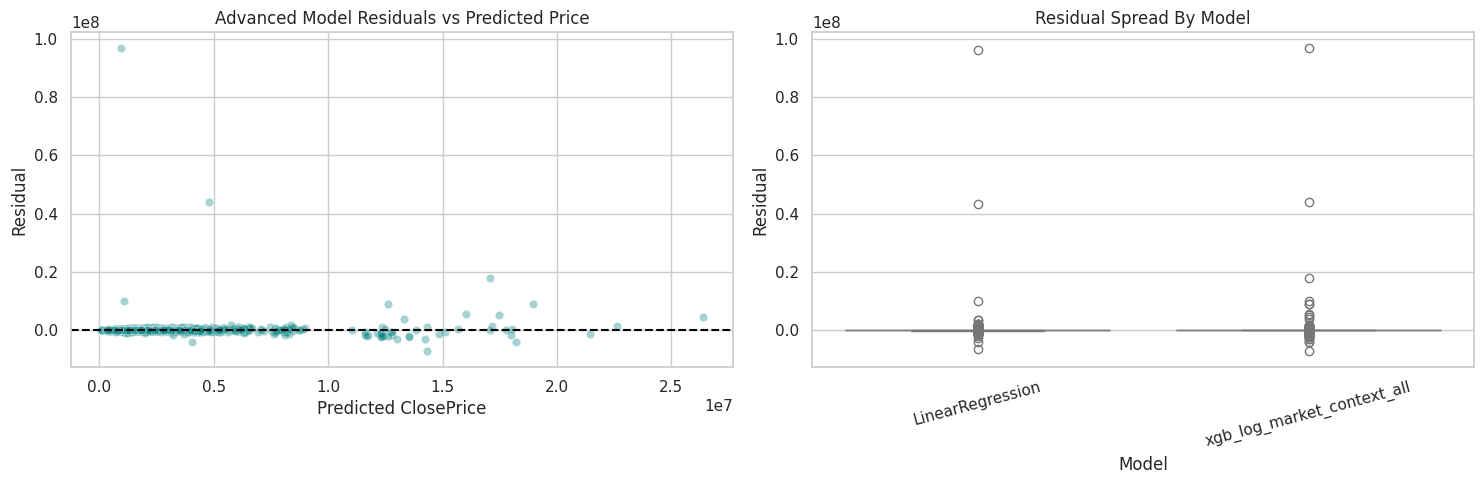

In [12]:
residual_long = prediction_df[["actual", "linear_residual", "advanced_residual"]].melt(
    id_vars="actual",
    value_vars=["linear_residual", "advanced_residual"],
    var_name="model",
    value_name="residual",
)
residual_long["model"] = residual_long["model"].replace(
    {"linear_residual": "LinearRegression", "advanced_residual": best_advanced_name}
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(
    data=prediction_df,
    x="best_advanced_predicted",
    y="advanced_residual",
    alpha=0.35,
    ax=axes[0],
    color="teal",
)
axes[0].axhline(0, linestyle="--", color="black")
axes[0].set_title("Advanced Model Residuals vs Predicted Price")
axes[0].set_xlabel("Predicted ClosePrice")
axes[0].set_ylabel("Residual")

sns.boxplot(
    data=residual_long, x="model", y="residual", ax=axes[1], color="lightsteelblue"
)
axes[1].set_title("Residual Spread By Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Residual")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Error By Price Segment

This view is important for real estate modeling because one overall metric can hide where the model actually works. Earlier notebooks showed that unusual low-price sales and ultra-luxury homes behave differently from the mainstream market.

,price_segment,row_count,linear_mape,advanced_mape,linear_mdape,advanced_mdape
0,<$300k,279,1.8523,1.4930,0.2705,0.0490
1,$300k-$500k,1419,0.2044,0.0357,0.1711,0.0217
2,$500k-$1M,4897,0.1894,0.0320,0.0969,0.0214
3,$1M-$3M,4686,0.1175,0.0422,0.0512,0.0288
4,$3M+,740,0.0842,0.0653,0.0678,0.0421


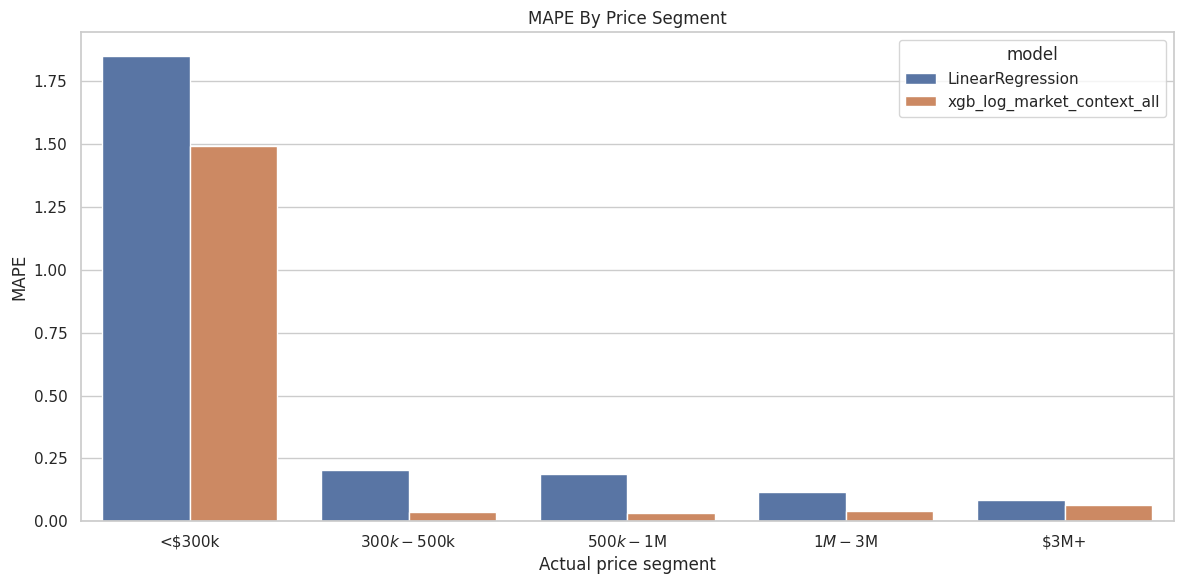

In [13]:
segment_df = prediction_df.copy()
segment_df["price_segment"] = pd.cut(
    segment_df["actual"],
    bins=[0, 300000, 500000, 1000000, 3000000, np.inf],
    labels=["<$300k", "$300k-$500k", "$500k-$1M", "$1M-$3M", "$3M+"],
)
segment_df["linear_ape"] = (
    segment_df["actual"] - segment_df["linear_predicted"]
).abs() / segment_df["actual"]
segment_df["advanced_ape"] = (
    segment_df["actual"] - segment_df["best_advanced_predicted"]
).abs() / segment_df["actual"]

segment_summary = (
    segment_df.groupby("price_segment", observed=True)
    .agg(
        row_count=("actual", "size"),
        linear_mape=("linear_ape", "mean"),
        advanced_mape=("advanced_ape", "mean"),
        linear_mdape=("linear_ape", "median"),
        advanced_mdape=("advanced_ape", "median"),
    )
    .reset_index()
)

display(segment_summary)

segment_plot = segment_summary.melt(
    id_vars=["price_segment", "row_count"],
    value_vars=["linear_mape", "advanced_mape"],
    var_name="model",
    value_name="MAPE",
)
segment_plot["model"] = segment_plot["model"].replace(
    {"linear_mape": "LinearRegression", "advanced_mape": best_advanced_name}
)

plt.figure(figsize=(12, 6))
sns.barplot(data=segment_plot, x="price_segment", y="MAPE", hue="model")
plt.title("MAPE By Price Segment")
plt.xlabel("Actual price segment")
plt.ylabel("MAPE")
plt.tight_layout()
plt.show()

## Prediction Sanity Checks

The first XGBoost attempt produced unrealistic predictions, so this table checks whether the final advanced models still create extreme prediction values.

In [14]:
sanity_rows = []
for model_name, preds in final_predictions.items():
    sanity_rows.append(
        {
            "model_name": model_name,
            "min_prediction": preds.min(),
            "max_prediction": preds.max(),
            "predictions_under_0": int((preds < 0).sum()),
            "predictions_over_50m": int((preds > 50000000).sum()),
        }
    )

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)

,model_name,min_prediction,max_prediction,predictions_under_0,predictions_over_50m
0,LinearRegression,61918.5643,31427594.0734,0,0
1,xgb_log_baseline_all,81742.9453,18564736.0000,0,0
2,xgb_log_market_context_all,72940.5312,26379218.0000,0,0
3,xgb_log_market_context_filtered,111449.8359,18026948.0000,0,0
4,xgb_log_reality_all,67936.2578,25502302.0000,0,0


## Feature Importance

This chart shows which processed features the best advanced model relied on most.

,feature,importance
0,num__ListPrice,0.4892
21,num__county_hist_median_closeprice,0.2262
10,num__log_living_area,0.0879
12,num__list_price_per_sqft,0.0740
1,num__LivingArea,0.0462
3,num__BathroomsTotalInteger,0.0258
24,num__district_hist_median_closeprice,0.0162
6,num__Latitude,0.0032
7,num__Longitude,0.0025
8,num__DaysOnMarket,0.0020


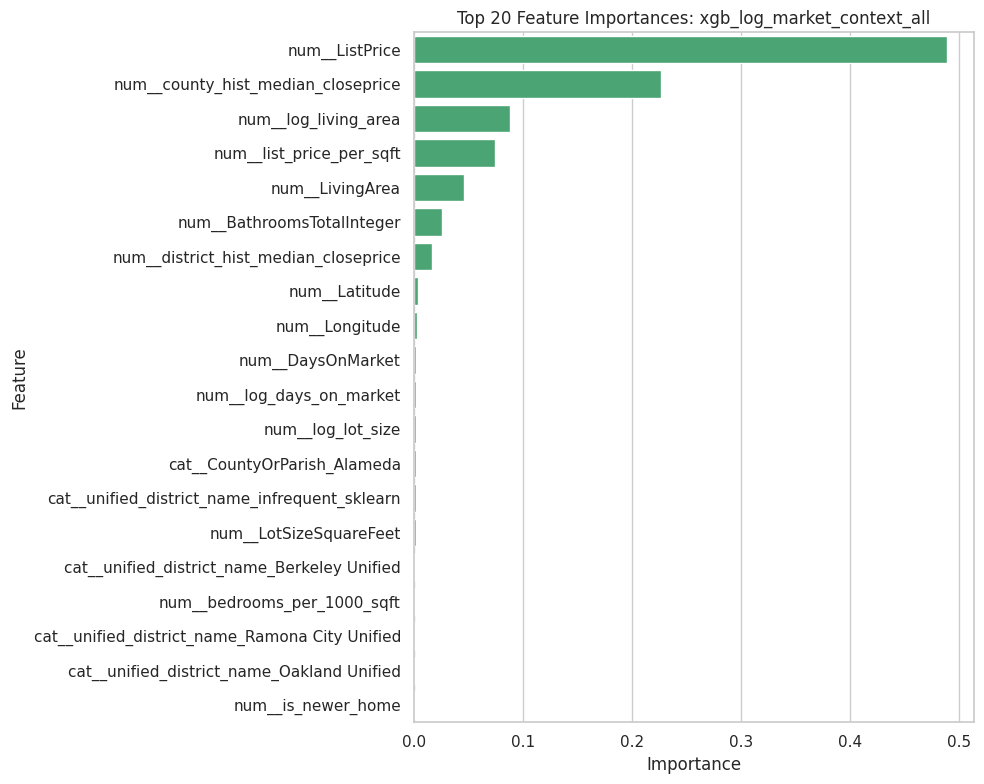

In [15]:
best_model = final_models[best_advanced_name]
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importances,
    }
).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20), x="importance", y="feature", color="mediumseagreen"
)
plt.title(f"Top 20 Feature Importances: {best_advanced_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [16]:
advanced_results_path = output_dir / "week7_advanced_model_results.csv"
tuning_results_path = output_dir / "week7_xgboost_tuning_results.csv"
predictions_path = output_dir / "week7_best_advanced_predictions.csv"
segment_results_path = output_dir / "week7_price_segment_results.csv"
sanity_results_path = output_dir / "week7_prediction_sanity_checks.csv"
importance_path = output_dir / "week7_feature_importance.csv"

final_results_df.to_csv(advanced_results_path, index=False)
tuning_results_df.to_csv(tuning_results_path, index=False)
prediction_df.to_csv(predictions_path, index=False)
segment_summary.to_csv(segment_results_path, index=False)
sanity_df.to_csv(sanity_results_path, index=False)
importance_df.to_csv(importance_path, index=False)

print(f"Saved final model results to {advanced_results_path}")
print(f"Saved tuning results to {tuning_results_path}")
print(f"Saved predictions to {predictions_path}")
print(f"Saved price-segment results to {segment_results_path}")
print(f"Saved prediction sanity checks to {sanity_results_path}")
print(f"Saved feature importance to {importance_path}")

Saved final model results to ../outputs/week7_advanced_model_results.csv
Saved tuning results to ../outputs/week7_xgboost_tuning_results.csv
Saved predictions to ../outputs/week7_best_advanced_predictions.csv
Saved price-segment results to ../outputs/week7_price_segment_results.csv
Saved prediction sanity checks to ../outputs/week7_prediction_sanity_checks.csv
Saved feature importance to ../outputs/week7_feature_importance.csv


## Final Week 7 Conclusion

Week 7 is complete once the tuned XGBoost experiments and final test metrics are saved. This notebook tests a stronger model family, uses log-target modeling to reduce the impact of extreme sale prices, and adds more realistic market-context features.

The final conclusion should compare whether the best XGBoost version beats the retained linear-regression baseline on the unchanged test month. If XGBoost improves the overall metrics or performs better in important price segments, it can become the new advanced-model candidate. If it does not, it remains a documented advanced-model experiment and the linear baseline stays the stronger retained specification.